<a href="https://colab.research.google.com/github/parmidamardi/CDM-TA-6/blob/main/CDM_TA_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Section 1

In [6]:
import torch
import torchvision.models as models

model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
middle_layer = model.layer3[0].conv1
W_middle = middle_layer.weight.detach()

final_layer = model.fc
W_final = final_layer.weight.detach()

In [12]:
W = W_final
W_conv = W_middle.view(W_middle.shape[0], -1)
U, S, Vh = torch.linalg.svd(W, full_matrices=False)

In [13]:
variance = S**2
explained_variance = variance / variance.sum()
cumulative_variance = torch.cumsum(explained_variance, dim=0)

In [16]:
k_95 = torch.searchsorted(cumulative_variance, 0.95).item() + 1
percent = 100 * k_95 / len(S)
print(k_95, percent)

291 56.8359375


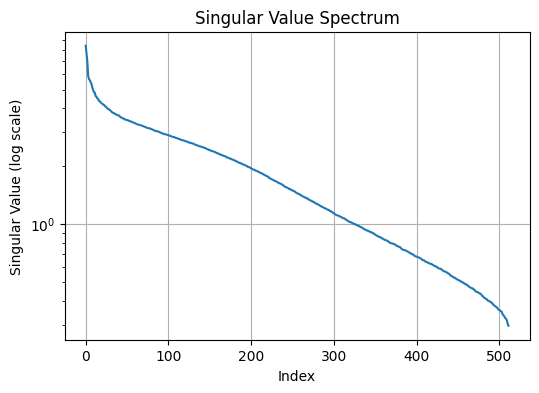

In [17]:
plt.figure(figsize=(6,4))
plt.semilogy(S.numpy())
plt.xlabel("Index")
plt.ylabel("Singular Value (log scale)")
plt.title("Singular Value Spectrum")
plt.grid(True)
plt.show()